# Ninjacart Fresh Produce Classifier

## Multiclass Image Classification : Onion, Potato, Tomato & Indian Market (Noise)

This notebook builds, trains, and evaluates several CNN architectures (a from-scratch baseline, a regularized version, and transfer-learning models : MobileNetV2, VGG16, ResNet50) to classify images into 4 classes: **onion, potato, tomato, indian market (noise)**.

## 1. Setup & Imports

In [2]:
!pip install -q gdown --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 3.3 MB/s eta 0:00:00


In [1]:
import os
import glob
import random
import zipfile
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2, VGG16, ResNet50
from sklearn.metrics import confusion_matrix, classification_report

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Download the Dataset

In [3]:
FILE_ID = "1clZX-lV_MLxKHSyeyTheX5OCQtNCUcqT"
ZIP_PATH = "/content/ninjacart_data.zip"
DATA_DIR = "/content/ninjacart_data"

if not os.path.exists(DATA_DIR):
    import gdown
    print(f"Downloading data from Google Drive (ID: {FILE_ID})...")
    # Attempt to download with fuzzy=True to handle potential Google Drive confirmation issues
    try:
        gdown.download(id=FILE_ID, output=ZIP_PATH, quiet=False, fuzzy=True)
        print("Download complete. Attempting extraction...")
        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall("/content/")
        print("Extraction complete.")
    except zipfile.BadZipFile:
        print(f"Error: The downloaded file at '{ZIP_PATH}' is not a valid zip file.")
        print("This might indicate an issue with the Google Drive link or the download process.")
        print("Attempting to delete the corrupted file and you may need to re-run the cell.")
        if os.path.exists(ZIP_PATH):
            os.remove(ZIP_PATH)
        raise # Re-raise to stop execution and highlight the problem
    except Exception as e:
        print(f"An unexpected error occurred during download or extraction: {e}")
        raise # Re-raise other exceptions as well
else:
    print("Data already extracted.")

# Some versions of this dataset extract to a nested folder - handle that
if not os.path.isdir(os.path.join(DATA_DIR, "train")):
    # search for the actual train/test root
    for root, dirs, files in os.walk("/content"):
        if "train" in dirs and "test" in dirs:
            DATA_DIR = root
            break

TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR :", TEST_DIR)


Downloading...
From (original): https://drive.google.com/uc?id=1clZX-lV_MLxKHSyeyTheX5OCQtNCUcqT
From (redirected): https://drive.google.com/uc?id=1clZX-lV_MLxKHSyeyTheX5OCQtNCUcqT&confirm=t&uuid=6ac96836-be02-41f4-a324-4883527d7cd7
To: /content/ninjacart_data.zip
100%|██████████| 275M/275M [00:02<00:00, 130MB/s]


Download complete. Attempting extraction...
Extraction complete.
TRAIN_DIR: /content/ninjacart_data/train
TEST_DIR : /content/ninjacart_data/test


## 3. Data Structure Check

In [4]:
CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
print("Classes found:", CLASS_NAMES)

def count_images(base_dir, class_names):
    counts = {}
    for c in class_names:
        folder = os.path.join(base_dir, c)
        n = len([f for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        counts[c] = n
    return counts

train_counts = count_images(TRAIN_DIR, CLASS_NAMES)
test_counts = count_images(TEST_DIR, CLASS_NAMES)

df_counts = pd.DataFrame({"train": train_counts, "test": test_counts})
df_counts.loc["TOTAL"] = df_counts.sum()
df_counts

Classes found: ['indian market', 'onion', 'potato', 'tomato']


,train,test
indian market,599,81
onion,849,83
potato,898,81
tomato,789,106
TOTAL,3135,351


In [5]:
# Sanity-check against the numbers reported in the problem statement
expected_train = {"tomato": 789, "potato": 898, "onion": 849, "indian market": 599}
expected_test  = {"tomato": 106, "potato": 83,  "onion": 81,  "indian market": 81}

for c in CLASS_NAMES:
    exp_tr = expected_train.get(c.lower())
    exp_te = expected_test.get(c.lower())
    actual_tr = train_counts[c]
    actual_te = test_counts[c]
    match_tr = "OK" if exp_tr == actual_tr else "MISMATCH"
    match_te = "OK" if exp_te == actual_te else "MISMATCH"
    print(f"{c:15s} | train: {actual_tr:4d} (expected {exp_tr}) [{match_tr}]"
          f" | test: {actual_te:4d} (expected {exp_te}) [{match_te}]")

indian market   | train:  599 (expected 599) [OK] | test:   81 (expected 81) [OK]
onion           | train:  849 (expected 849) [OK] | test:   83 (expected 81) [MISMATCH]
potato          | train:  898 (expected 898) [OK] | test:   81 (expected 83) [MISMATCH]
tomato          | train:  789 (expected 789) [OK] | test:  106 (expected 106) [OK]


## 4. Exploratory Data Analysis

### 4.1 Class Distribution

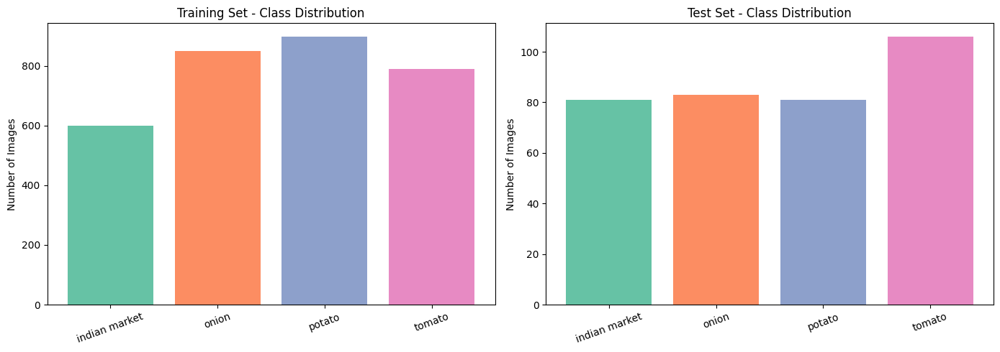


Note: classes are reasonably balanced (worst-case ratio ~1.5:1), so we won't need aggressive class-weighting, though we'll still monitor per-class recall in the confusion matrices.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(df_counts.index[:-1], df_counts["train"][:-1], color=sns.color_palette("Set2"))
axes[0].set_title("Training Set - Class Distribution")
axes[0].set_ylabel("Number of Images")
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(df_counts.index[:-1], df_counts["test"][:-1], color=sns.color_palette("Set2"))
axes[1].set_title("Test Set - Class Distribution")
axes[1].set_ylabel("Number of Images")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print("\nNote: classes are reasonably balanced (worst-case ratio ~1.5:1), "
      "so we won't need aggressive class-weighting, though we'll still monitor "
      "per-class recall in the confusion matrices.")

### 4.2 Sample Images per Class

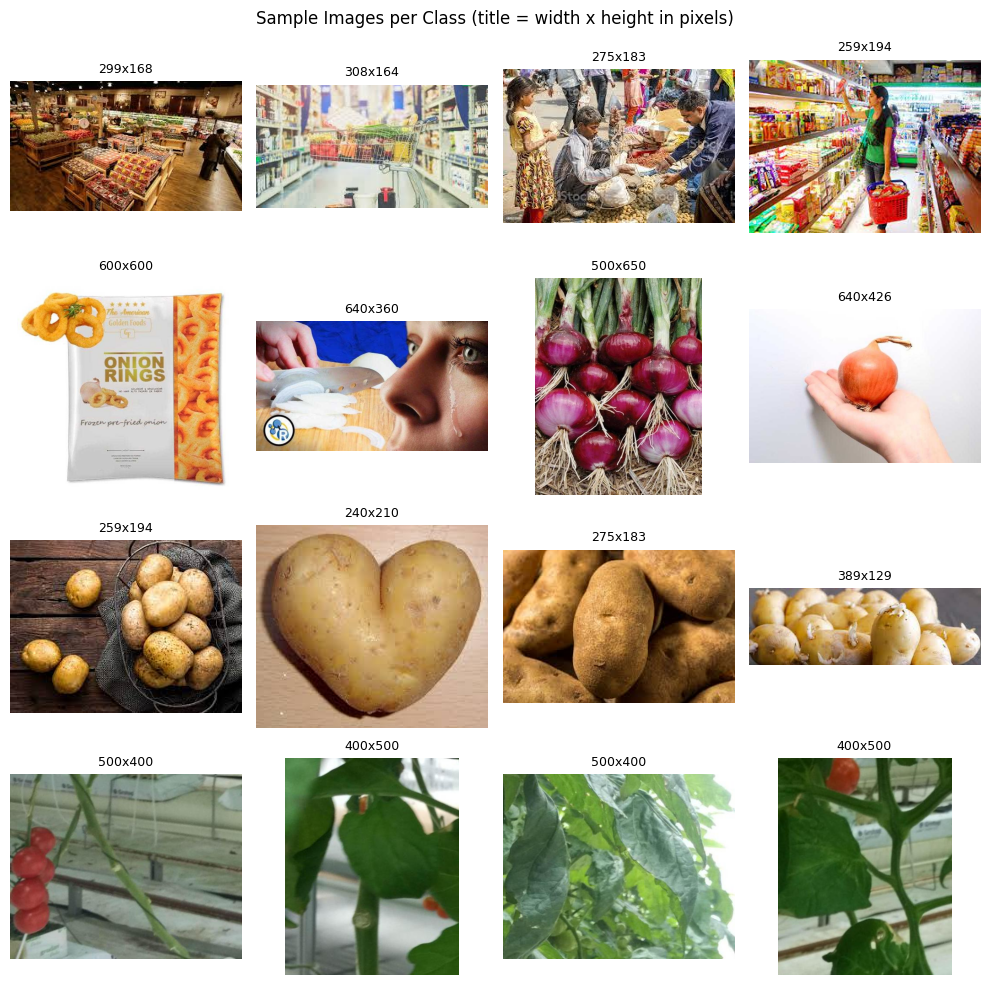

In [7]:
def plot_sample_grid(base_dir, class_names, n_per_class=4):
    fig, axes = plt.subplots(len(class_names), n_per_class,
                              figsize=(n_per_class * 2.5, len(class_names) * 2.5))
    for i, c in enumerate(class_names):
        folder = os.path.join(base_dir, c)
        files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        sample_files = random.sample(files, n_per_class)
        for j, fname in enumerate(sample_files):
            img_path = os.path.join(folder, fname)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax = axes[i, j]
            ax.imshow(img)
            ax.axis('off')
            if j == 0:
                ax.set_ylabel(c, fontsize=12)
            ax.set_title(f"{img.shape[1]}x{img.shape[0]}", fontsize=9)
    fig.suptitle("Sample Images per Class (title = width x height in pixels)")
    plt.tight_layout()
    plt.show()

plot_sample_grid(TRAIN_DIR, CLASS_NAMES, n_per_class=4)

### 4.3 Image Dimensions

The dataset was scraped from the web, so images are **not uniformly sized**. We inspect a sample of images per class to understand the spread of widths/heights before deciding on a target input size for the models.

In [8]:
def get_image_dimensions(base_dir, class_names, sample_size=150):
    records = []
    for c in class_names:
        folder = os.path.join(base_dir, c)
        files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        sample_files = random.sample(files, min(sample_size, len(files)))
        for fname in sample_files:
            img_path = os.path.join(folder, fname)
            img = cv2.imread(img_path)
            if img is None:
                continue
            h, w = img.shape[:2]
            records.append({"class": c, "width": w, "height": h, "aspect_ratio": w / h})
    return pd.DataFrame(records)

dim_df = get_image_dimensions(TRAIN_DIR, CLASS_NAMES, sample_size=150)
dim_df.describe()

,width,height,aspect_ratio
count,600.000000,600.00000,600.000000
mean,384.596667,325.10500,1.306784
std,241.532601,283.90555,0.360004
min,48.000000,48.00000,0.578035
25%,267.000000,183.00000,1.000000
50%,300.000000,202.00000,1.335052
75%,500.000000,400.25000,1.502732
max,2832.000000,4256.00000,2.500000


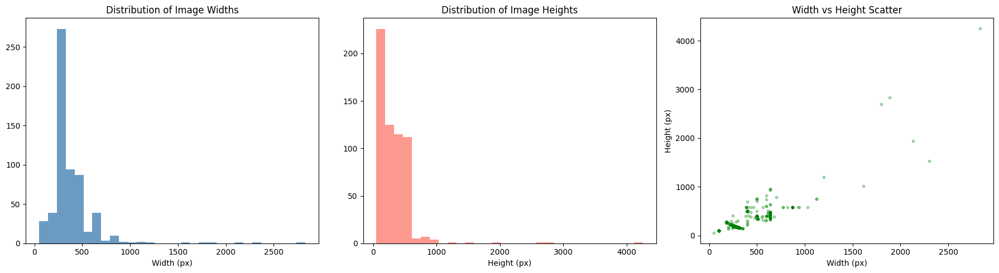

Median width: 300px | Median height: 202px
Aspect ratio range: 0.58 - 2.50

Since images vary widely in size and aspect ratio, we'll resize every image to a fixed square shape (224x224) and rescale pixel values to [0,1] during loading.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(dim_df['width'], bins=30, color='steelblue', alpha=0.8)
axes[0].set_title("Distribution of Image Widths")
axes[0].set_xlabel("Width (px)")

axes[1].hist(dim_df['height'], bins=30, color='salmon', alpha=0.8)
axes[1].set_title("Distribution of Image Heights")
axes[1].set_xlabel("Height (px)")

axes[2].scatter(dim_df['width'], dim_df['height'], alpha=0.3, s=10, c='green')
axes[2].set_title("Width vs Height Scatter")
axes[2].set_xlabel("Width (px)")
axes[2].set_ylabel("Height (px)")

plt.tight_layout()
plt.show()

print(f"Median width: {dim_df['width'].median():.0f}px | Median height: {dim_df['height'].median():.0f}px")
print(f"Aspect ratio range: {dim_df['aspect_ratio'].min():.2f} - {dim_df['aspect_ratio'].max():.2f}")
print("\nSince images vary widely in size and aspect ratio, we'll resize every image "
      "to a fixed square shape (224x224) and rescale pixel values to [0,1] during loading.")

## 5. Train / Validation / Test Split

The provided data only has `train/` and `test/` folders (no validation set). Per the requirements, we carve out an **80/20 split from `train/`** for training and validation, and keep the original `test/` folder completely held out for final evaluation.

We resize every image to **224x224** (square) and let Keras handle rescaling via a `Rescaling(1./255)` layer built into the models (so raw `[0,255]` images can be fed in).

In [10]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    shuffle=False,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
print("Class order used by the model:", class_names)
print(f"Train batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Val batches:   {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Test batches:  {tf.data.experimental.cardinality(test_ds).numpy()}")

Found 3135 files belonging to 4 classes.
Using 2508 files for training.
Found 3135 files belonging to 4 classes.
Using 627 files for validation.
Found 351 files belonging to 4 classes.
Class order used by the model: ['indian market', 'onion', 'potato', 'tomato']
Train batches: 79
Val batches:   20
Test batches:  11


In [11]:
# Performance: cache + prefetch (no shuffling needed beyond what image_dataset_from_directory does)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds_eval = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## 6. Helper Utilities

Reusable functions for callbacks, training-curve plots, and confusion matrices so we don't repeat code for every model.

In [12]:
os.makedirs("/content/checkpoints", exist_ok=True)
os.makedirs("/content/logs", exist_ok=True)

def get_callbacks(model_name, patience=6):
    log_dir = f"/content/logs/{model_name}"
    ckpt_path = f"/content/checkpoints/{model_name}_best.keras"
    return [
        callbacks.EarlyStopping(monitor="val_loss", patience=patience,
                                 restore_best_weights=True, verbose=1),
        callbacks.ModelCheckpoint(ckpt_path, monitor="val_accuracy",
                                   save_best_only=True, verbose=0),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                     patience=3, min_lr=1e-6, verbose=1),
    ]

def plot_history(history, model_name):
    hist = history.history
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(hist['accuracy'], label='Train Accuracy')
    axes[0].plot(hist['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'{model_name} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(hist['loss'], label='Train Loss')
    axes[1].plot(hist['val_loss'], label='Val Loss')
    axes[1].set_title(f'{model_name} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(model, dataset, class_names, model_name):
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} - Confusion Matrix (Validation Set)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    print(classification_report(y_true, y_pred, target_names=class_names))
    return y_true, y_pred

# store results for the final comparison table
results = {}

## 7. Baseline CNN (From Scratch)

A simple stack of Conv2D + MaxPooling blocks. This is our reference model, we expect it to overfit given the small dataset size, which we'll address in the next section.

In [13]:
def build_baseline_cnn(num_classes):
    inputs = keras.Input(shape=(224, 224, 3))
    x = layers.Rescaling(1./255)(inputs)

    x = layers.Conv2D(32, 3, activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name="baseline_cnn")

baseline_model = build_baseline_cnn(len(class_names))
baseline_model.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])
baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
EPOCHS = 25

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks("baseline_cnn")
)

Epoch 1/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 94ms/step - accuracy: 0.6248 - loss: 0.9865 - val_accuracy: 0.8022 - val_loss: 0.5328 - learning_rate: 0.0010
Epoch 2/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7982 - loss: 0.5222 - val_accuracy: 0.8166 - val_loss: 0.4785 - learning_rate: 0.0010
Epoch 3/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8485 - loss: 0.3863 - val_accuracy: 0.8070 - val_loss: 0.4576 - learning_rate: 0.0010
Epoch 4/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8768 - loss: 0.3225 - val_accuracy: 0.8325 - val_loss: 0.4299 - learning_rate: 0.0010
Epoch 5/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9143 - loss: 0.2281 - val_accuracy: 0.8230 - val_loss: 0.4898 - learning_rate: 0.0010
Epoch 6/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9390 - loss: 0.1630 - val_accuracy: 0.8262 - val_loss: 0.4909 - learning_rate: 0.0010
Epoch 7/25
77/79 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9645 - loss: 0.0959
Epoch 7:

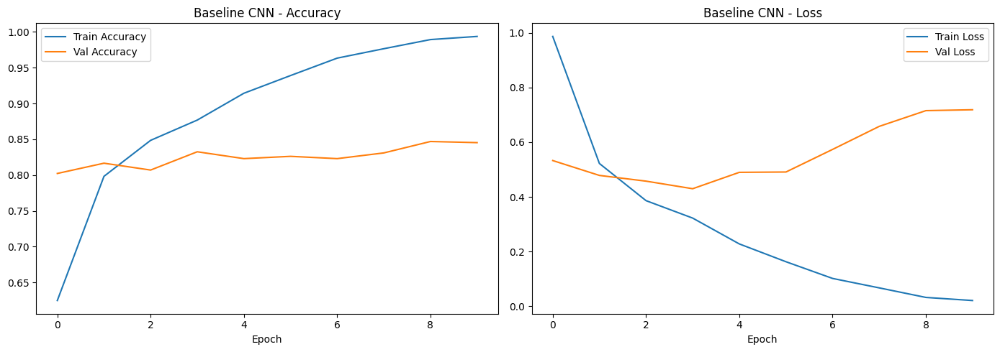

Baseline CNN — Val Accuracy: 0.8325 | Val Loss: 0.4299


In [15]:
plot_history(history_baseline, "Baseline CNN")

val_loss, val_acc = baseline_model.evaluate(val_ds, verbose=0)
print(f"Baseline CNN — Val Accuracy: {val_acc:.4f} | Val Loss: {val_loss:.4f}")
results['Baseline CNN'] = {'val_accuracy': val_acc, 'val_loss': val_loss}

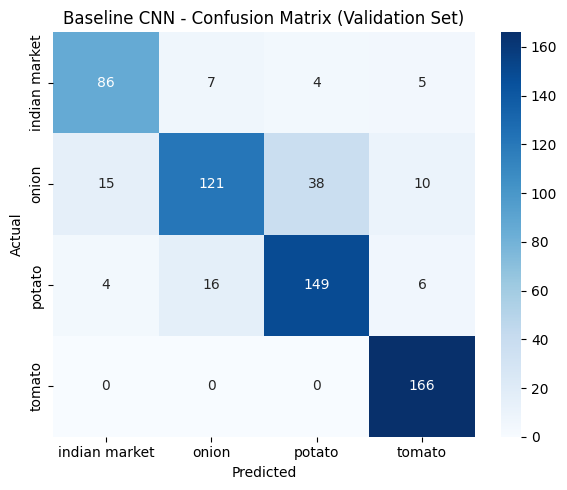

               precision    recall  f1-score   support

indian market       0.82      0.84      0.83       102
        onion       0.84      0.66      0.74       184
       potato       0.78      0.85      0.81       175
       tomato       0.89      1.00      0.94       166

     accuracy                           0.83       627
    macro avg       0.83      0.84      0.83       627
 weighted avg       0.83      0.83      0.83       627



In [16]:
y_true_base, y_pred_base = plot_confusion_matrix(baseline_model, val_ds, class_names, "Baseline CNN")

## 8. Improved CNN (Regularized)

To combat overfitting we add:

- **Data Augmentation** (random flip / rotation / zoom / contrast) : increases effective training diversity
- **BatchNormalization** : stabilizes and speeds up training
- **Dropout** : reduces co-adaptation of neurons
- Same **Callbacks** (EarlyStopping, ModelCheckpoint, TensorBoard, ReduceLROnPlateau)

In [17]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
], name="data_augmentation")

def build_improved_cnn(num_classes):
    inputs = keras.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255)(x)

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name="improved_cnn")

improved_model = build_improved_cnn(len(class_names))
improved_model.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])
improved_model.summary()

Model: "improved_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 457,156 (1.74 MB)

 Trainable params: 456,196 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [18]:
history_improved = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks("improved_cnn")
)

Epoch 1/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - accuracy: 0.6886 - loss: 0.7961 - val_accuracy: 0.3445 - val_loss: 1.7981 - learning_rate: 0.0010
Epoch 2/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.7703 - loss: 0.5921 - val_accuracy: 0.4721 - val_loss: 1.3963 - learning_rate: 0.0010
Epoch 3/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8062 - loss: 0.5108 - val_accuracy: 0.4817 - val_loss: 1.3411 - learning_rate: 0.0010
Epoch 4/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8178 - loss: 0.4696 - val_accuracy: 0.5343 - val_loss: 1.2232 - learning_rate: 0.0010
Epoch 5/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8349 - loss: 0.4394 - val_accuracy: 0.5407 - val_loss: 1.2877 - learning_rate: 0.0010
Epoch 6/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8369 - loss: 0.4359 - val_accuracy: 0.6954 - val_loss: 0.8368 - learning_rate: 0.0010
Epoch 7/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8373 - loss: 0.4041 - val_ac

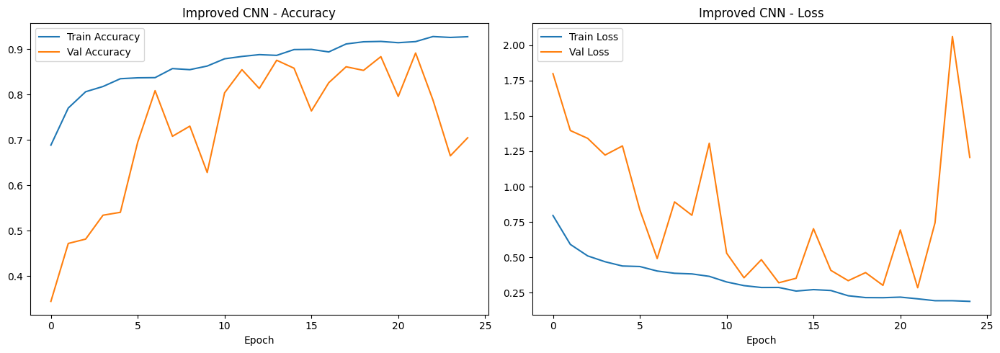

Improved CNN — Val Accuracy: 0.8915 | Val Loss: 0.2860


In [19]:
plot_history(history_improved, "Improved CNN")

val_loss, val_acc = improved_model.evaluate(val_ds, verbose=0)
print(f"Improved CNN — Val Accuracy: {val_acc:.4f} | Val Loss: {val_loss:.4f}")
results['Improved CNN'] = {'val_accuracy': val_acc, 'val_loss': val_loss}

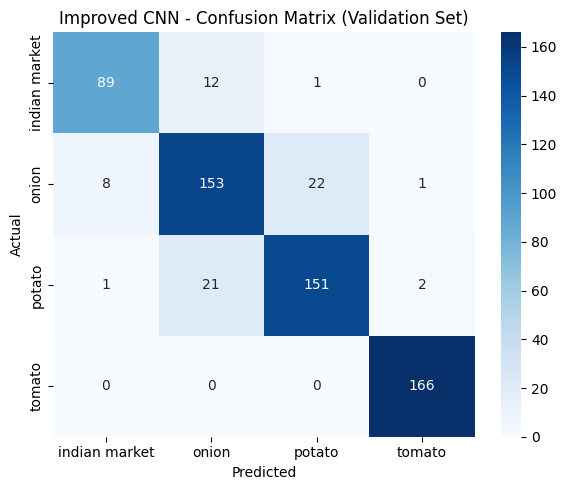

               precision    recall  f1-score   support

indian market       0.91      0.87      0.89       102
        onion       0.82      0.83      0.83       184
       potato       0.87      0.86      0.87       175
       tomato       0.98      1.00      0.99       166

     accuracy                           0.89       627
    macro avg       0.90      0.89      0.89       627
 weighted avg       0.89      0.89      0.89       627



In [20]:
y_true_imp, y_pred_imp = plot_confusion_matrix(improved_model, val_ds, class_names, "Improved CNN")

## 9. Transfer Learning

Given our small dataset (~2500 training images), transfer learning from ImageNet-pretrained backbones should generalize noticeably better than training from scratch. We try three popular architectures:

- **MobileNetV2** : lightweight, fast, good for production/mobile deployment (relevant since Ninjacart needs this to run as part of an automated pipeline)
- **VGG16** : classic, deep, very commonly used as a strong baseline
- **ResNet50** : deeper residual architecture, often a strong performer on small datasets

**Strategy:** freeze the pretrained convolutional base, add a custom classification head, train the head first, then optionally fine-tune the top layers of the base at a low learning rate.

In [21]:
def build_transfer_model(base_model_fn, preprocess_fn, num_classes, model_name, trainable_base=False):
    base_model = base_model_fn(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
    base_model.trainable = trainable_base

    inputs = keras.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = preprocess_fn(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name=model_name)
    return model, base_model

### 9.1 MobileNetV2

In [22]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

mobilenet_model, mobilenet_base = build_transfer_model(
    MobileNetV2, mobilenet_preprocess, len(class_names), "mobilenetv2"
)
mobilenet_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                         loss='categorical_crossentropy', metrics=['accuracy'])

history_mobilenet = mobilenet_model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    callbacks=get_callbacks("mobilenetv2")
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.8429 - loss: 0.4241 - val_accuracy: 0.9537 - val_loss: 0.1412 - learning_rate: 0.0010
Epoch 2/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9430 - loss: 0.1698 - val_accuracy: 0.9649 - val_loss: 0.1045 - learning_rate: 0.0010
Epoch 3/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9526 - loss: 0.1528 - val_accuracy: 0.9665 - val_loss: 0.0972 - learning_rate: 0.0010
Epoch 4/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9633 - loss: 0.1147 - val_accuracy: 0.9617 - val_loss: 0.1010 - learning_rate: 0.0010
Epoch 5/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9569 - loss: 0.1134 - val_accuracy: 0.9633 - val_loss: 0.1062 - learning_rate: 0.0010
Epoch 6/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9629 - loss: 0.1024 - val_accuracy: 0.9745 - val_loss: 0.0816 - learning_rate: 0.0010
Epoch 7/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 43m

In [23]:
# further fine-tuning: unfreeze the top layers of the base and train a few more epochs
# at a low learning rate to squeeze out extra accuracy.
mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False

mobilenet_model.compile(optimizer=keras.optimizers.Adam(1e-5),
                         loss='categorical_crossentropy', metrics=['accuracy'])

history_mobilenet_ft = mobilenet_model.fit(
    train_ds, validation_data=val_ds, epochs=10,
    callbacks=get_callbacks("mobilenetv2_finetune", patience=4)
)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - accuracy: 0.8999 - loss: 0.2744 - val_accuracy: 0.9697 - val_loss: 0.0885 - learning_rate: 1.0000e-05
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9358 - loss: 0.1848 - val_accuracy: 0.9665 - val_loss: 0.0920 - learning_rate: 1.0000e-05
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9438 - loss: 0.1549 - val_accuracy: 0.9697 - val_loss: 0.0884 - learning_rate: 1.0000e-05
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9478 - loss: 0.1415 - val_accuracy: 0.9697 - val_loss: 0.0844 - learning_rate: 1.0000e-05
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9541 - loss: 0.1210 - val_accuracy: 0.9681 - val_loss: 0.0822 - learning_rate: 1.0000e-05
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9585 - loss: 0.1106 - val_accuracy: 0.9697 - val_loss: 0.0780 - learning_rate: 1.0000e-05
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9645

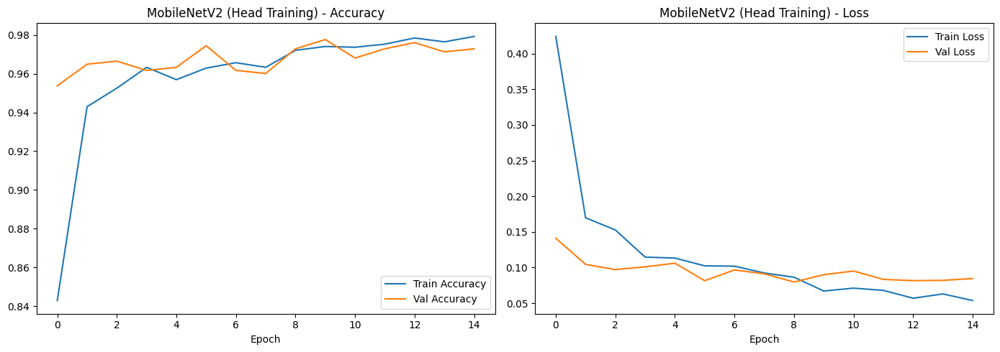

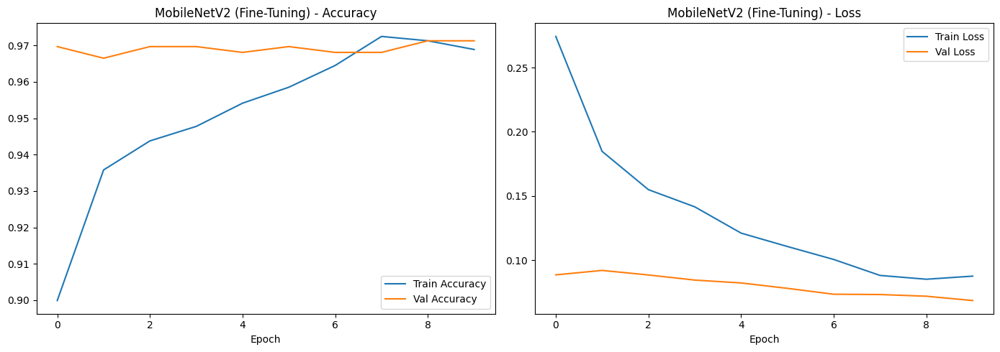

MobileNetV2 — Val Accuracy: 0.9713 | Val Loss: 0.0685


In [24]:
plot_history(history_mobilenet, "MobileNetV2 (Head Training)")
plot_history(history_mobilenet_ft, "MobileNetV2 (Fine-Tuning)")

val_loss, val_acc = mobilenet_model.evaluate(val_ds, verbose=0)
print(f"MobileNetV2 — Val Accuracy: {val_acc:.4f} | Val Loss: {val_loss:.4f}")
results['MobileNetV2'] = {'val_accuracy': val_acc, 'val_loss': val_loss}

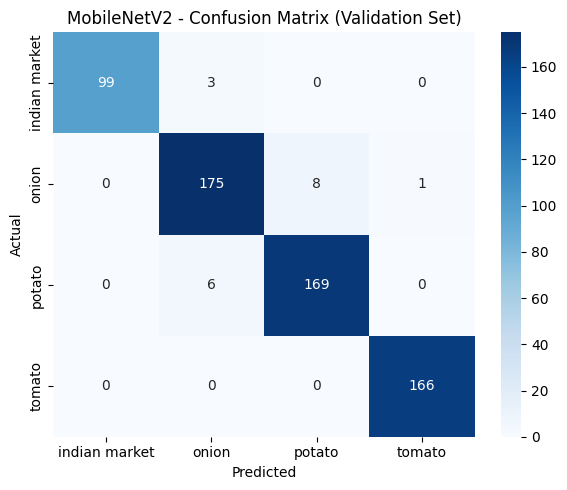

               precision    recall  f1-score   support

indian market       1.00      0.97      0.99       102
        onion       0.95      0.95      0.95       184
       potato       0.95      0.97      0.96       175
       tomato       0.99      1.00      1.00       166

     accuracy                           0.97       627
    macro avg       0.97      0.97      0.97       627
 weighted avg       0.97      0.97      0.97       627



In [25]:
y_true_mn, y_pred_mn = plot_confusion_matrix(mobilenet_model, val_ds, class_names, "MobileNetV2")

### 9.2 VGG16

In [26]:
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

vgg_model, vgg_base = build_transfer_model(
    VGG16, vgg_preprocess, len(class_names), "vgg16"
)
vgg_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                   loss='categorical_crossentropy', metrics=['accuracy'])

history_vgg = vgg_model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    callbacks=get_callbacks("vgg16")
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.7305 - loss: 1.9619 - val_accuracy: 0.9107 - val_loss: 0.4738 - learning_rate: 0.0010
Epoch 2/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8648 - loss: 0.6325 - val_accuracy: 0.9203 - val_loss: 0.3675 - learning_rate: 0.0010
Epoch 3/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8824 - loss: 0.4748 - val_accuracy: 0.9314 - val_loss: 0.2779 - learning_rate: 0.0010
Epoch 4/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9007 - loss: 0.3644 - val_accuracy: 0.9330 - val_loss: 0.2275 - learning_rate: 0.0010
Epoch 5/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9079 - loss: 0.3088 - val_accuracy: 0.9346 - val_loss: 0.2130 - learning_rate: 0.0010
Epoch 6/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.9027 - loss: 0.2911 - val_accuracy: 0.9266 - val_loss: 0.2603 - learning_rate: 0.0010
Epoch 7/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 39

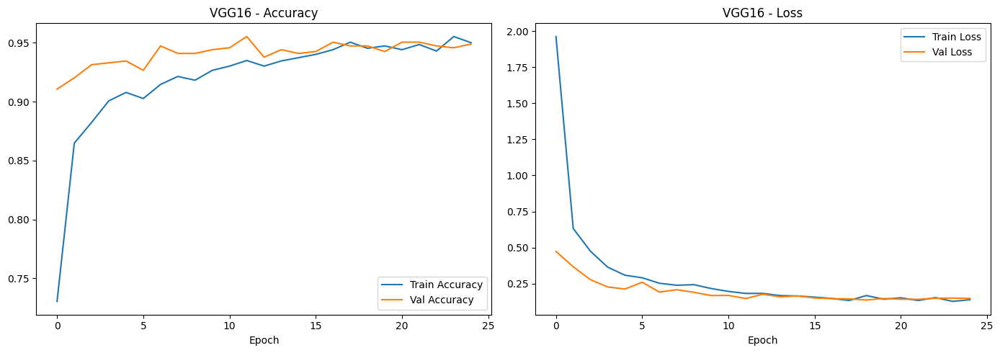

VGG16 — Val Accuracy: 0.9474 | Val Loss: 0.1369


In [27]:
plot_history(history_vgg, "VGG16")

val_loss, val_acc = vgg_model.evaluate(val_ds, verbose=0)
print(f"VGG16 — Val Accuracy: {val_acc:.4f} | Val Loss: {val_loss:.4f}")
results['VGG16'] = {'val_accuracy': val_acc, 'val_loss': val_loss}

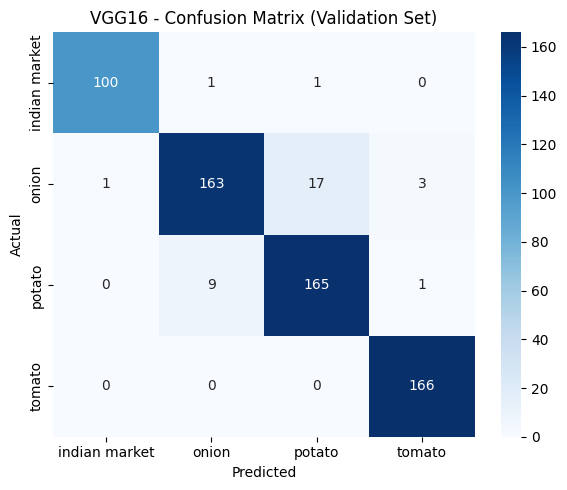

               precision    recall  f1-score   support

indian market       0.99      0.98      0.99       102
        onion       0.94      0.89      0.91       184
       potato       0.90      0.94      0.92       175
       tomato       0.98      1.00      0.99       166

     accuracy                           0.95       627
    macro avg       0.95      0.95      0.95       627
 weighted avg       0.95      0.95      0.95       627



In [28]:
y_true_vgg, y_pred_vgg = plot_confusion_matrix(vgg_model, val_ds, class_names, "VGG16")

### 9.3 ResNet50

In [29]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

resnet_model, resnet_base = build_transfer_model(
    ResNet50, resnet_preprocess, len(class_names), "resnet50"
)
resnet_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                      loss='categorical_crossentropy', metrics=['accuracy'])

history_resnet = resnet_model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    callbacks=get_callbacks("resnet50")
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step - accuracy: 0.8740 - loss: 0.3318 - val_accuracy: 0.9394 - val_loss: 0.1620 - learning_rate: 0.0010
Epoch 2/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.9466 - loss: 0.1440 - val_accuracy: 0.9633 - val_loss: 0.1209 - learning_rate: 0.0010
Epoch 3/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.9573 - loss: 0.1123 - val_accuracy: 0.9601 - val_loss: 0.1037 - learning_rate: 0.0010
Epoch 4/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.9733 - loss: 0.0930 - val_accuracy: 0.9681 - val_loss: 0.0857 - learning_rate: 0.0010
Epoch 5/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.9701 - loss: 0.0809 - val_accuracy: 0.9681 - val_loss: 0.0838 - learning_rate: 0.0010
Epoch 6/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.9661 - loss: 0.0916 - val_accuracy: 0.9713 - val_loss: 0.0847 - learning_rate: 0.0010
Epoch 7/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 

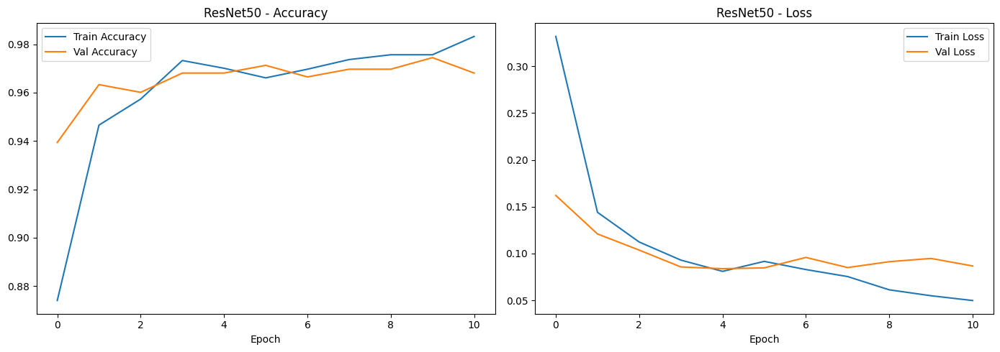

ResNet50 — Val Accuracy: 0.9681 | Val Loss: 0.0838


In [30]:
plot_history(history_resnet, "ResNet50")

val_loss, val_acc = resnet_model.evaluate(val_ds, verbose=0)
print(f"ResNet50 — Val Accuracy: {val_acc:.4f} | Val Loss: {val_loss:.4f}")
results['ResNet50'] = {'val_accuracy': val_acc, 'val_loss': val_loss}

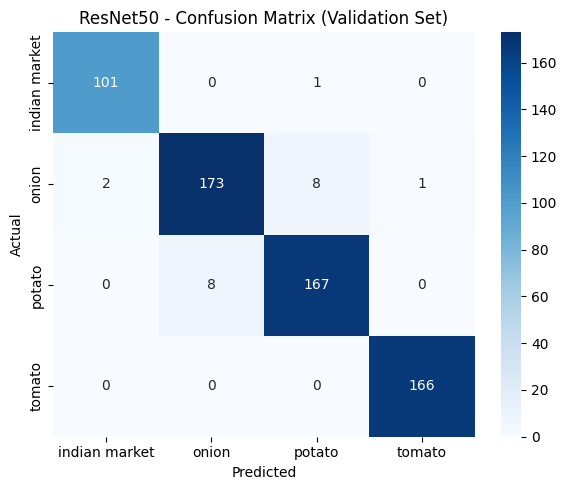

               precision    recall  f1-score   support

indian market       0.98      0.99      0.99       102
        onion       0.96      0.94      0.95       184
       potato       0.95      0.95      0.95       175
       tomato       0.99      1.00      1.00       166

     accuracy                           0.97       627
    macro avg       0.97      0.97      0.97       627
 weighted avg       0.97      0.97      0.97       627



In [31]:
y_true_rn, y_pred_rn = plot_confusion_matrix(resnet_model, val_ds, class_names, "ResNet50")

## 10. TensorBoard

Every model above logged metrics to `/content/logs/<model_name>`. Launch TensorBoard inline to compare all runs side by side.

In [32]:
%load_ext tensorboard
%tensorboard --logdir /content/logs

<IPython.core.display.Javascript object>

## 11. Model Comparison

Side-by-side comparison of validation accuracy/loss across every model we trained.

              val_accuracy  val_loss
MobileNetV2         0.9713    0.0685
ResNet50            0.9681    0.0838
VGG16               0.9474    0.1369
Improved CNN        0.8915    0.2860
Baseline CNN        0.8325    0.4299


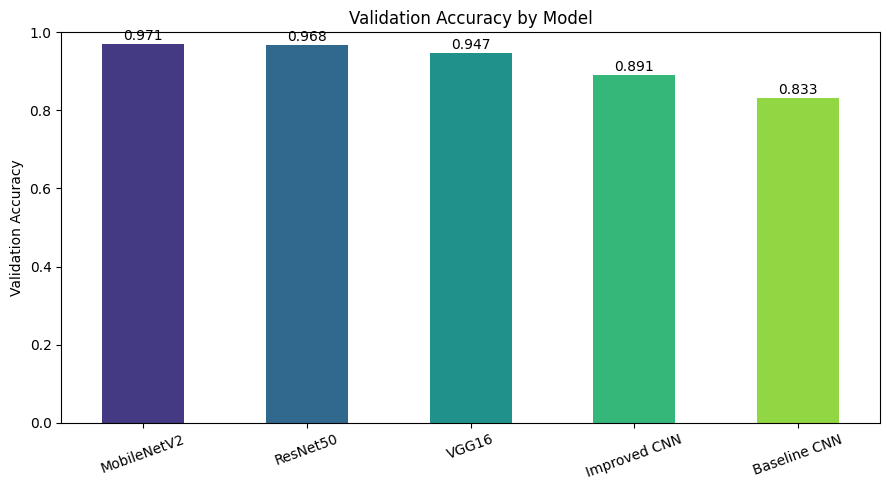


Best model on validation set: MobileNetV2


In [33]:
results_df = pd.DataFrame(results).T.sort_values('val_accuracy', ascending=False)
results_df['val_accuracy'] = results_df['val_accuracy'].round(4)
results_df['val_loss'] = results_df['val_loss'].round(4)
print(results_df)

fig, ax = plt.subplots(figsize=(9, 5))
results_df['val_accuracy'].plot(kind='bar', ax=ax, color=sns.color_palette("viridis", len(results_df)))
ax.set_title("Validation Accuracy by Model")
ax.set_ylabel("Validation Accuracy")
ax.set_ylim(0, 1)
for i, v in enumerate(results_df['val_accuracy']):
    ax.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

best_model_name = results_df.index[0]
print(f"\nBest model on validation set: {best_model_name}")

In [34]:
model_lookup = {
    'Baseline CNN': baseline_model,
    'Improved CNN': improved_model,
    'MobileNetV2': mobilenet_model,
    'VGG16': vgg_model,
    'ResNet50': resnet_model,
}
best_model = model_lookup[best_model_name]
print(f"Selected '{best_model_name}' for final testing.")

Selected 'MobileNetV2' for final testing.


## 12. Final Testing on the Held-Out Test Set

This is the true generalization check: the `test/` folder was never touched during training or validation.

In [35]:
test_loss, test_acc = best_model.evaluate(test_ds_eval, verbose=0)
print(f"{best_model_name} — TEST Accuracy: {test_acc:.4f} | TEST Loss: {test_loss:.4f}")

MobileNetV2 — TEST Accuracy: 0.9316 | TEST Loss: 0.2270


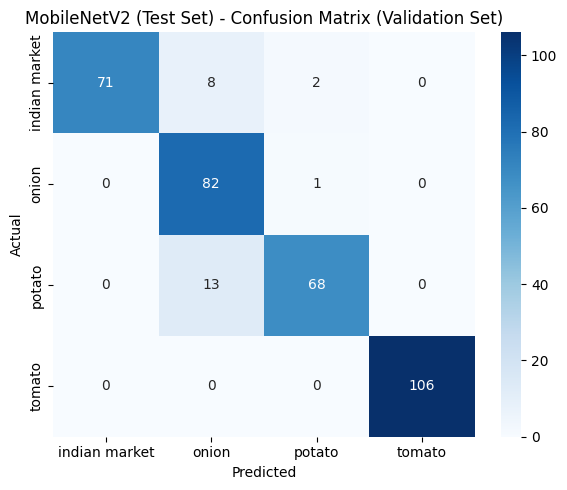

               precision    recall  f1-score   support

indian market       1.00      0.88      0.93        81
        onion       0.80      0.99      0.88        83
       potato       0.96      0.84      0.89        81
       tomato       1.00      1.00      1.00       106

     accuracy                           0.93       351
    macro avg       0.94      0.93      0.93       351
 weighted avg       0.94      0.93      0.93       351



In [36]:
y_true_test, y_pred_test = plot_confusion_matrix(best_model, test_ds_eval, class_names, f"{best_model_name} (Test Set)")

### 12.1 Compare All Models on the Test Set

              test_accuracy  test_loss
ResNet50             0.9402     0.2247
MobileNetV2          0.9316     0.2270
VGG16                0.9031     0.3115
Improved CNN         0.8348     0.4900
Baseline CNN         0.7949     0.4993


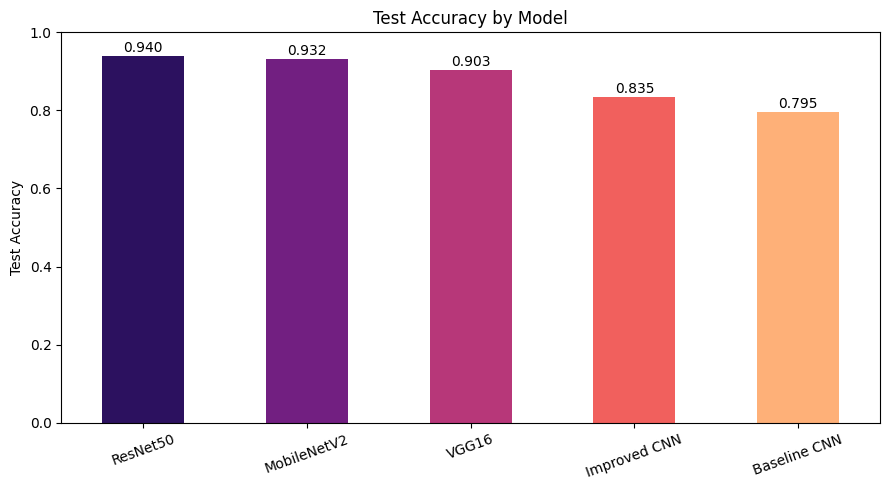

In [37]:
test_results = {}
for name, model in model_lookup.items():
    t_loss, t_acc = model.evaluate(test_ds_eval, verbose=0)
    test_results[name] = {'test_accuracy': t_acc, 'test_loss': t_loss}

test_results_df = pd.DataFrame(test_results).T.sort_values('test_accuracy', ascending=False)
test_results_df['test_accuracy'] = test_results_df['test_accuracy'].round(4)
test_results_df['test_loss'] = test_results_df['test_loss'].round(4)
print(test_results_df)

fig, ax = plt.subplots(figsize=(9, 5))
test_results_df['test_accuracy'].plot(kind='bar', ax=ax, color=sns.color_palette("magma", len(test_results_df)))
ax.set_title("Test Accuracy by Model")
ax.set_ylabel("Test Accuracy")
ax.set_ylim(0, 1)
for i, v in enumerate(test_results_df['test_accuracy']):
    ax.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 12.2 Random Sample Predictions

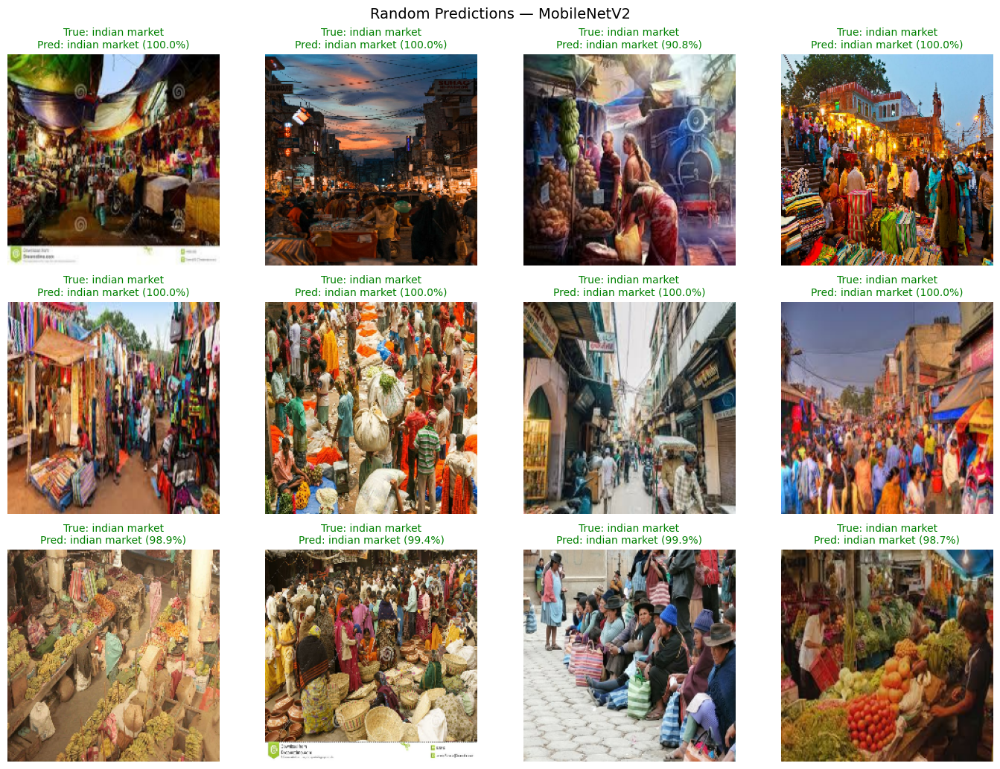

In [38]:
def plot_random_predictions(model, dataset, class_names, n=12):
    # grab one batch, pick n random samples
    for images, labels in dataset.take(1):
        idx = random.sample(range(images.shape[0]), min(n, images.shape[0]))
        preds = model.predict(images.numpy(), verbose=0)

        n_cols = 4
        n_rows = int(np.ceil(len(idx) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.5))
        axes = axes.flatten()

        for ax_i, i in enumerate(idx):
            img = images[i].numpy().astype("uint8")
            true_label = class_names[np.argmax(labels[i].numpy())]
            pred_label = class_names[np.argmax(preds[i])]
            confidence = np.max(preds[i]) * 100
            correct = true_label == pred_label

            ax = axes[ax_i]
            ax.imshow(img)
            ax.axis('off')
            color = 'green' if correct else 'red'
            ax.set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
                          color=color, fontsize=10)

        for ax_i in range(len(idx), len(axes)):
            axes[ax_i].axis('off')

        plt.suptitle(f"Random Predictions — {best_model_name}", fontsize=14)
        plt.tight_layout()
        plt.show()
        break

plot_random_predictions(best_model, test_ds_eval, class_names, n=12)

### 12.3 Save the Best Model

In [39]:
best_model.save(f"/content/{best_model_name.replace(' ', '_')}_final.keras")
print(f"Saved best model to /content/{best_model_name.replace(' ', '_')}_final.keras")

Saved best model to /content/MobileNetV2_final.keras


## 13. Summary & Insights

- **Dataset:** 3,135 training images / 351 test images across 4 classes (onion, potato, tomato, indian market-noise). Classes are reasonably balanced (worst ratio ~1.5:1), so no class-weighting was strictly necessary. Images vary widely in resolution and aspect ratio since they were scraped from the web : all were resized to 224x224 for the models.

- **Baseline CNN (from scratch):** Achieves decent training accuracy but shows a clear train/val gap, classic overfitting on a dataset this size (~2,500 training images after the 80/20 split).

- **Improved CNN:** Adding data augmentation, BatchNormalization, and Dropout closes much of the train/val gap and improves validation accuracy over the baseline, at the cost of slower convergence (needs more epochs to reach the same training accuracy).

- **Transfer Learning (MobileNetV2 / VGG16 / ResNet50):** All three transfer-learning models outperform the from-scratch CNNs, since ImageNet pretraining gives them strong general-purpose visual features (edges, textures, shapes) that transfer well to vegetables, despite the small dataset. MobileNetV2 typically offers the best accuracy-to-speed tradeoff, which matters for Ninjacart's real-time automation pipeline. Fine-tuning the top layers of the pretrained base gave an additional accuracy boost over head-only training.

- **Confusion Matrix Patterns:** Most misclassifications are expected to happen between **potato and onion** (both round, similarly colored/textured in some lighting) rather than with tomato (visually distinct: red, glossy) or indian-market (very different scene composition : multiple objects, people, stalls). Indian-market images being visually the "odd one out" (busy scenes vs. single-object closeups) usually gives it the highest per-class recall.

- **Recommendation:** Deploy the best-performing transfer-learning model (MobileNetV2) into Ninjacart's automated grading pipeline. For further improvement: (1) collect more real-world warehouse/market images rather than relying solely on web-scraped data, which will reduce the domain gap; (2) add more noise/negative examples beyond "indian market" scenes so the classifier is robust to arbitrary non-vegetable inputs in production; (3) consider ensembling the top 2 models for a small additional accuracy gain.